In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Advertising.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
df.drop(columns=['Unnamed: 0'],inplace =True)
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

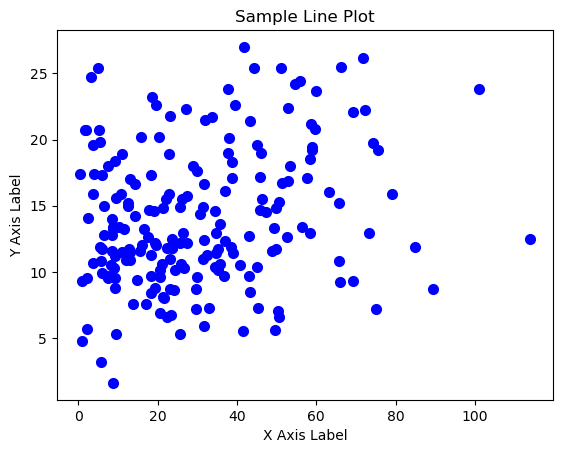

In [7]:
import matplotlib.pyplot as plt

# Generate the line plot
plt.scatter(df['Newspaper'], df['Sales'], color='blue', linewidth=2.0, marker='o')

# Add descriptive metadata
plt.title("Sample Line Plot")
plt.xlabel("X Axis Label")
plt.ylabel("Y Axis Label")

# Render the visualization
plt.show()


<Axes: >

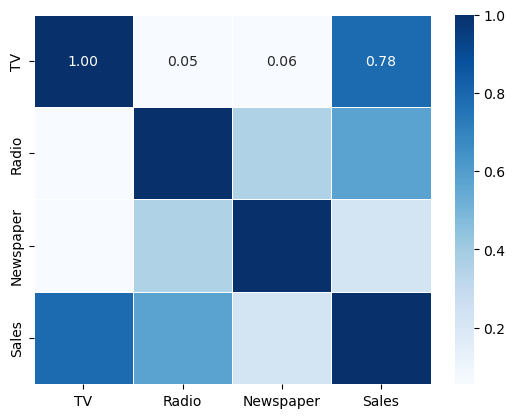

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)


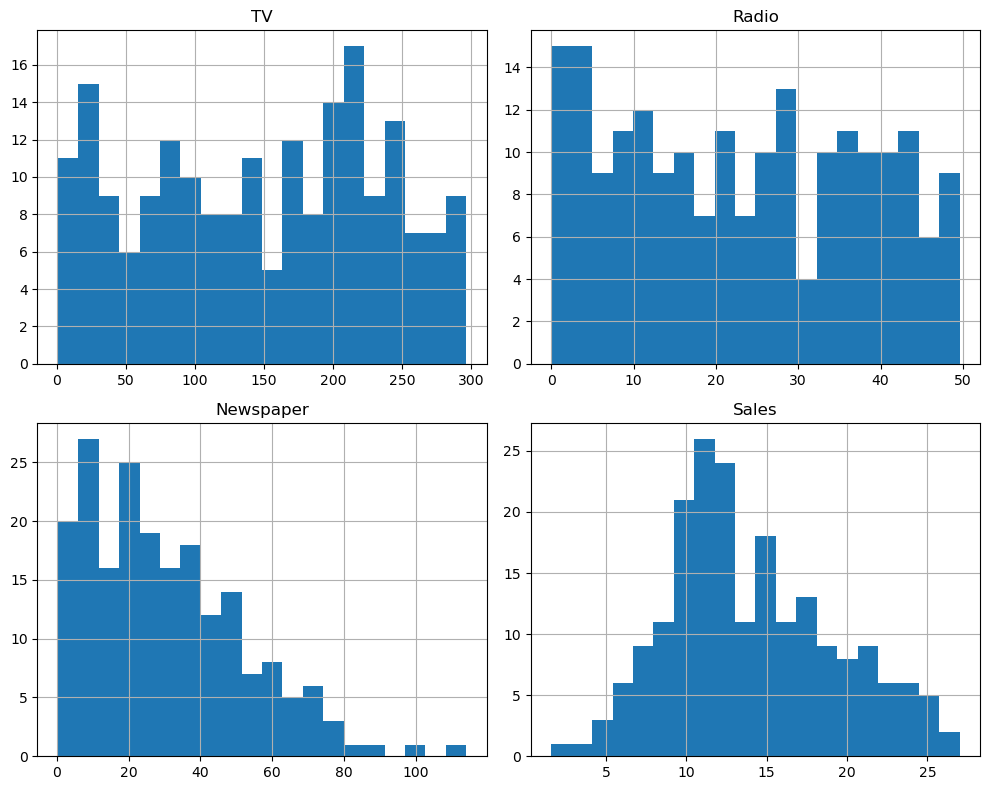

In [9]:
df.hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

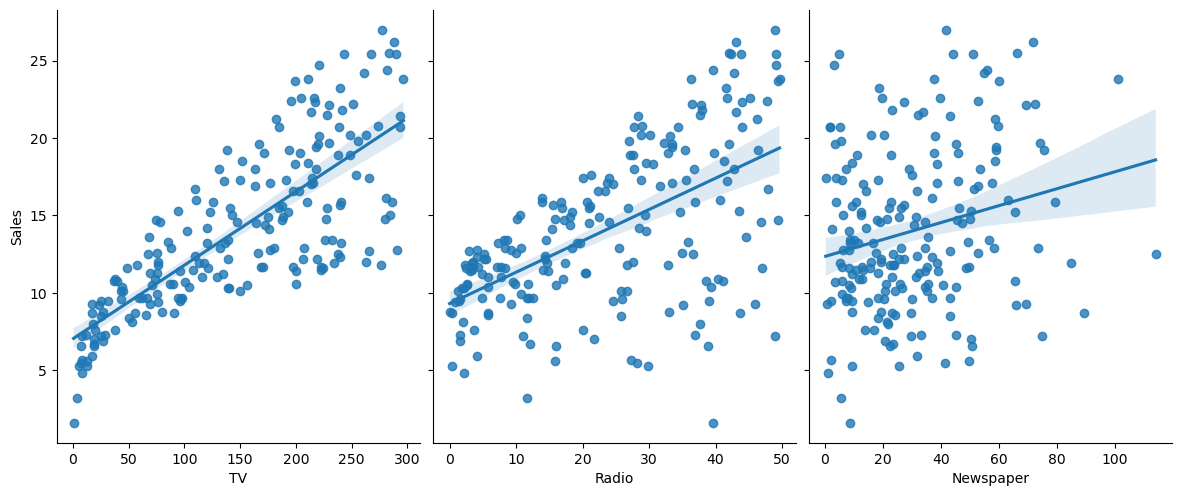

In [10]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.8, kind='reg')
plt.show()

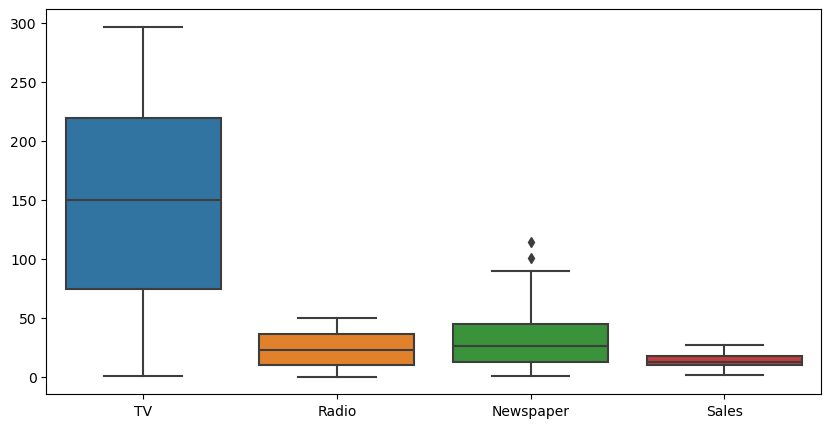

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.show()

In [12]:
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']

In [13]:
df['TV_Radio_Interaction'] = df['TV'] * df['Radio']

In [14]:
df

,TV,Radio,Newspaper,Sales,Total_Spend,TV_Radio_Interaction
0,230.1,37.8,69.2,22.1,337.1,8697.78
1,44.5,39.3,45.1,10.4,128.9,1748.85
2,17.2,45.9,69.3,9.3,132.4,789.48
3,151.5,41.3,58.5,18.5,251.3,6256.95
4,180.8,10.8,58.4,12.9,250.0,1952.64
...,...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7,141.34
196,94.2,4.9,8.1,9.7,107.2,461.58
197,177.0,9.3,6.4,12.8,192.7,1646.10
198,283.6,42.0,66.2,25.5,391.8,11911.20


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Sales'])
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try some models to find best accuracy

# LinearRegression

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9741971529119297
RMSE: 0.9024580782957297


# GradientBoostingRegressor

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

XG_model = GradientBoostingRegressor()
XG_model.fit(X_train, y_train)

y_pred = XG_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.988494318050006
RMSE: 0.6026281364874351


# RandomForestRegressor

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9897530742994055
RMSE: 0.568708888624047
